In [15]:
import importlib

import experiment
import experiment.config
import experiment.data
import experiment.rolling_forecast.runner

importlib.reload(experiment.config)
importlib.reload(experiment.data)
importlib.reload(experiment.rolling_forecast.runner)
importlib.reload(experiment)

from experiment import DatasetBuilder, ModelSpec, RollingForecastRunner, RunConfig


In [ ]:
CSV_PATH = './data/33101.csv'
UNIQUE_ID = 'ZJ'

INPUT_SIZE = 96
HORIZON = 7
SPLIT_RATIO = (7, 1, 2)
SLIDING_STEP_SIZE = 1

USE_EXOG = True
# USE_EXOG = False

SAVE_PLOTS = True
RANDOM_SEED = 2026
EARLY_STOP_PATIENCE_STEPS = 7
VAL_CHECK_STEPS = 5
ML_EARLY_STOPPING_ROUNDS = 20
# Neural training/validation loss
# Options:
# - 'MAE'
# - 'MSE'
# - 'RMSE'
# - 'MAPE'
# - 'SMAPE'
# - 'HuberLoss'   optional params: {'delta': 1.0}
# - 'TukeyLoss'   optional params: {'c': 4.685, 'normalize': True}
# - 'MASE'        required params: {'seasonality': 7}
NEURAL_LOSS_NAME = 'MAE'
NEURAL_LOSS_PARAMS = {}
PLOT_FORECAST = True
PLOT_LOSS = True
SAVE_DIR = './artifacts'

prepared_dataset = DatasetBuilder.from_csv(
    csv_path=CSV_PATH,
    unique_id=UNIQUE_ID,
)

run_config = RunConfig(
    input_size=INPUT_SIZE,
    horizon=HORIZON,
    split_ratio=SPLIT_RATIO,
    sliding_step_size=SLIDING_STEP_SIZE,
    use_exog=USE_EXOG,
    save_plots=SAVE_PLOTS,
    random_seed=RANDOM_SEED,
    early_stop_patience_steps=EARLY_STOP_PATIENCE_STEPS,
    val_check_steps=VAL_CHECK_STEPS,
    ml_early_stopping_rounds=ML_EARLY_STOPPING_ROUNDS,
    neural_loss_name=NEURAL_LOSS_NAME,
    neural_loss_params=NEURAL_LOSS_PARAMS,
    save_dir=SAVE_DIR,
    plot_forecast=PLOT_FORECAST,
    plot_loss=PLOT_LOSS,
)

runner = RollingForecastRunner(
    prepared_dataset=prepared_dataset,
    run_config=run_config,
)

len(prepared_dataset.futr_exog)


47

Seed set to 2026
Seed set to 2026


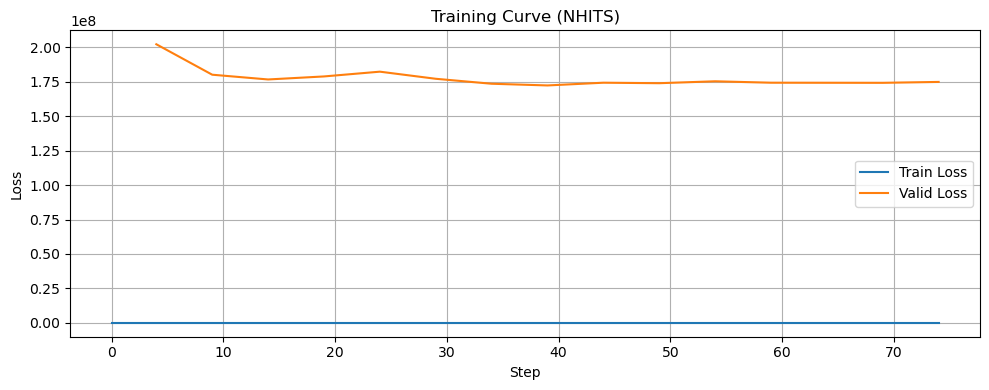

Seed set to 2026


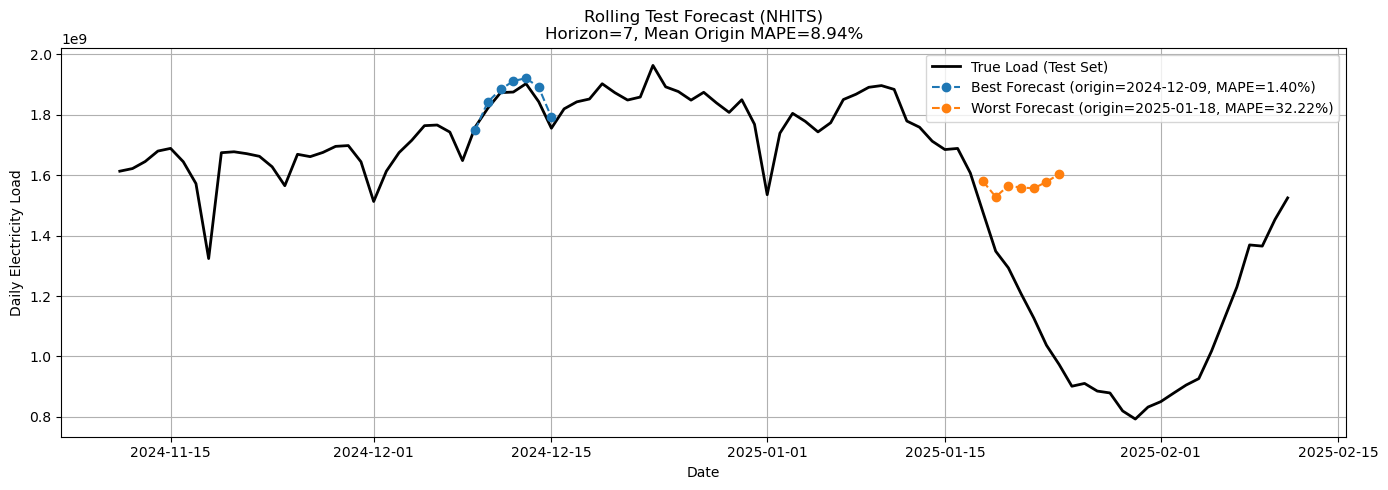

{'model_name': 'NHITS', 'val_overall_mape': 8.393480280821878, 'overall_mape': 8.940258320023789, 'skipped': False, 'skip_reason': None, 'artifact_dir': 'artifacts\\NHITS_feat\\20260409_164727', 'best_model_path': 'artifacts\\NHITS_feat\\20260409_164727\\checkpoints\\final.ckpt', 'rolling_raw_path': 'artifacts\\NHITS_feat\\20260409_164727\\rolling_test_raw.csv'}
rolling_raw_path: artifacts\NHITS_feat\20260409_164727\rolling_test_raw.csv


In [17]:
from neuralforecast.models import NHITS

nhits_spec = ModelSpec(
    name='NHITS',
    model_type='neural',
    model_cls=NHITS,
    model_params={
        'max_steps': 100,
        'learning_rate': 1e-3,
        'scaler_type': 'standard',
    },
    supports_future_exog=True,
)

nhits_result = runner.run(nhits_spec)
print(nhits_result.summary())
print(f"rolling_raw_path: {nhits_result.rolling_raw_path}")


Seed set to 2026
Seed set to 2026


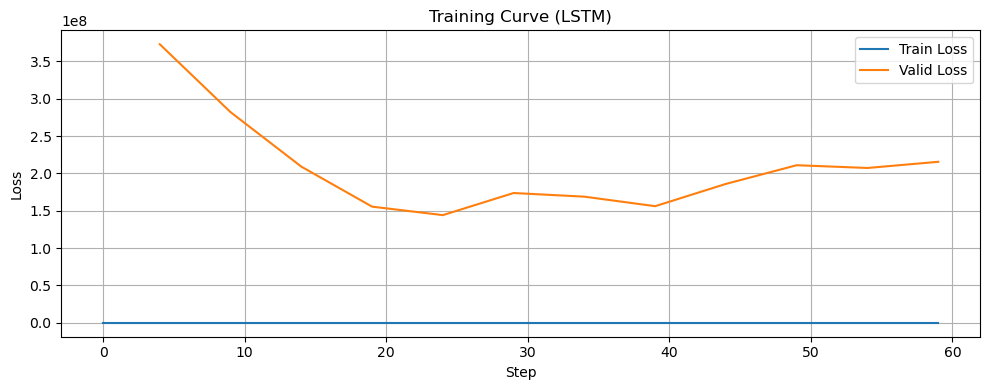

Seed set to 2026


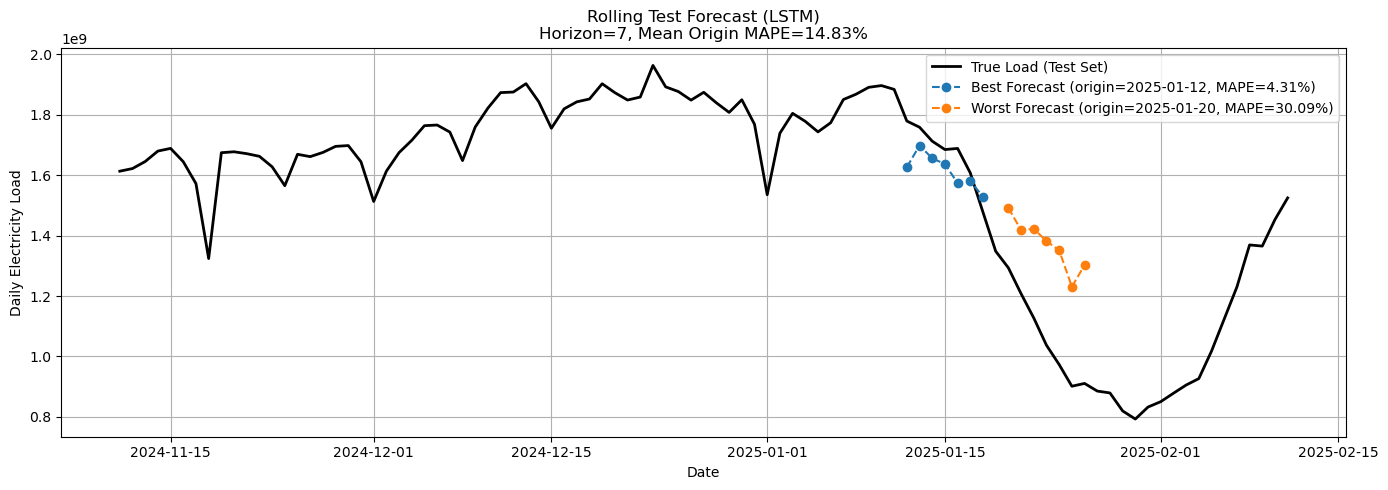

{'model_name': 'LSTM', 'val_overall_mape': 11.743635699246928, 'overall_mape': 14.829664495024435, 'skipped': False, 'skip_reason': None, 'artifact_dir': 'artifacts\\LSTM_feat\\20260409_164901', 'best_model_path': 'artifacts\\LSTM_feat\\20260409_164901\\checkpoints\\final.ckpt', 'rolling_raw_path': 'artifacts\\LSTM_feat\\20260409_164901\\rolling_test_raw.csv'}
rolling_raw_path: artifacts\LSTM_feat\20260409_164901\rolling_test_raw.csv


In [18]:
from neuralforecast.models import LSTM

lstm_spec = ModelSpec(
    name='LSTM',
    model_type='neural',
    model_cls=LSTM,
    model_params={
        'encoder_hidden_size': 64,
        'encoder_n_layers': 2,
        'encoder_dropout': 0.1,
        'decoder_hidden_size': 64,
        'decoder_layers': 2,
        'max_steps': 100,
        'learning_rate': 1e-3,
        'scaler_type': 'standard',
    },
    supports_future_exog=True,
)

lstm_result = runner.run(lstm_spec)
print(lstm_result.summary())
print(f"rolling_raw_path: {lstm_result.rolling_raw_path}")


Seed set to 2026


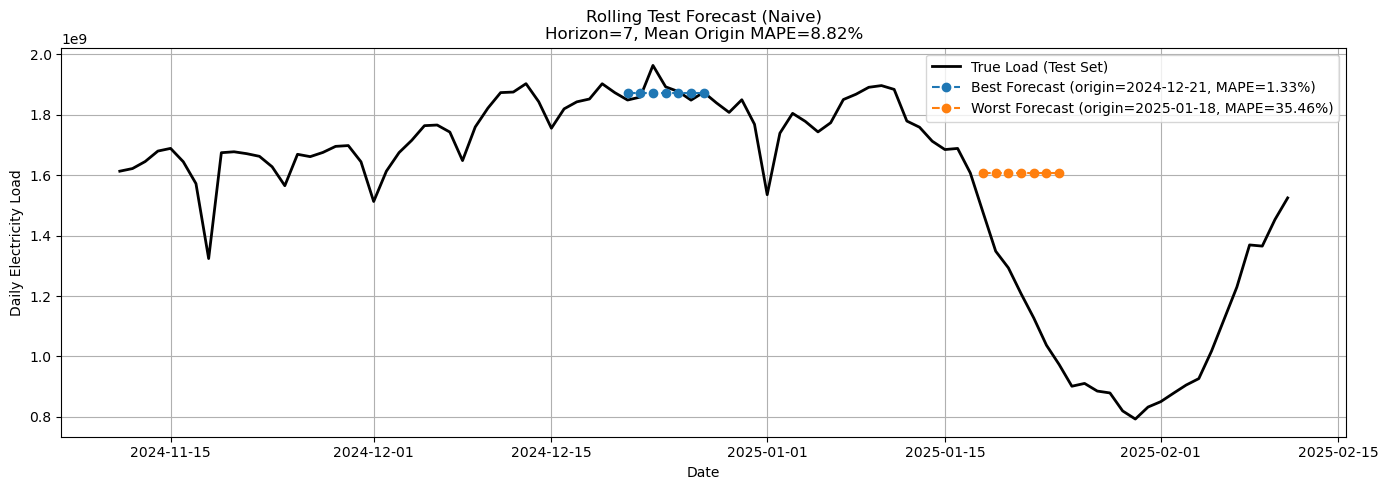

{'model_name': 'Naive', 'val_overall_mape': 7.798298665691358, 'overall_mape': 8.820472000008197, 'skipped': False, 'skip_reason': None, 'artifact_dir': 'artifacts\\Naive_no_feat\\20260409_164932', 'best_model_path': None, 'rolling_raw_path': 'artifacts\\Naive_no_feat\\20260409_164932\\rolling_test_raw.csv'}
rolling_raw_path: artifacts\Naive_no_feat\20260409_164932\rolling_test_raw.csv


In [19]:
from statsforecast.models import Naive

naive_spec = ModelSpec(
    name='Naive',
    model_type='stats',
    model_cls=Naive,
    model_params={},
)

naive_result = runner.run(naive_spec)
print(naive_result.summary())
print(f"rolling_raw_path: {naive_result.rolling_raw_path}")


In [20]:
from neuralforecast.models import PatchTST

patchtst_spec = ModelSpec(
    name='PatchTST',
    model_type='neural',
    model_cls=PatchTST,
    model_params={
        'n_heads': 4,
        'hidden_size': 128,
        'dropout': 0.1,
        'max_steps': 100,
        'learning_rate': 1e-3,
    },
    supports_future_exog=False,
)

patchtst_result = runner.run(patchtst_spec)
print(patchtst_result.summary())
print(f"rolling_raw_path: {patchtst_result.rolling_raw_path}")


{'model_name': 'PatchTST', 'val_overall_mape': nan, 'overall_mape': nan, 'skipped': True, 'skip_reason': 'PatchTST does not support future exogenous variables while RunConfig.use_exog=True.', 'artifact_dir': None, 'best_model_path': None, 'rolling_raw_path': None}
rolling_raw_path: None


Seed set to 2026


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001199 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10631
[LightGBM] [Info] Number of data points in the train set: 231, number of used features: 141
[LightGBM] [Info] Start training from score 1803428891.151515
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

d:\miniconda\envs\dl\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
d:\miniconda\envs\dl\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
d:\miniconda\envs\dl\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
d:\miniconda\envs\dl\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
d:\miniconda\envs\dl\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
d:\miniconda\envs\dl\Lib\site-packages\sklearn\utils\validat

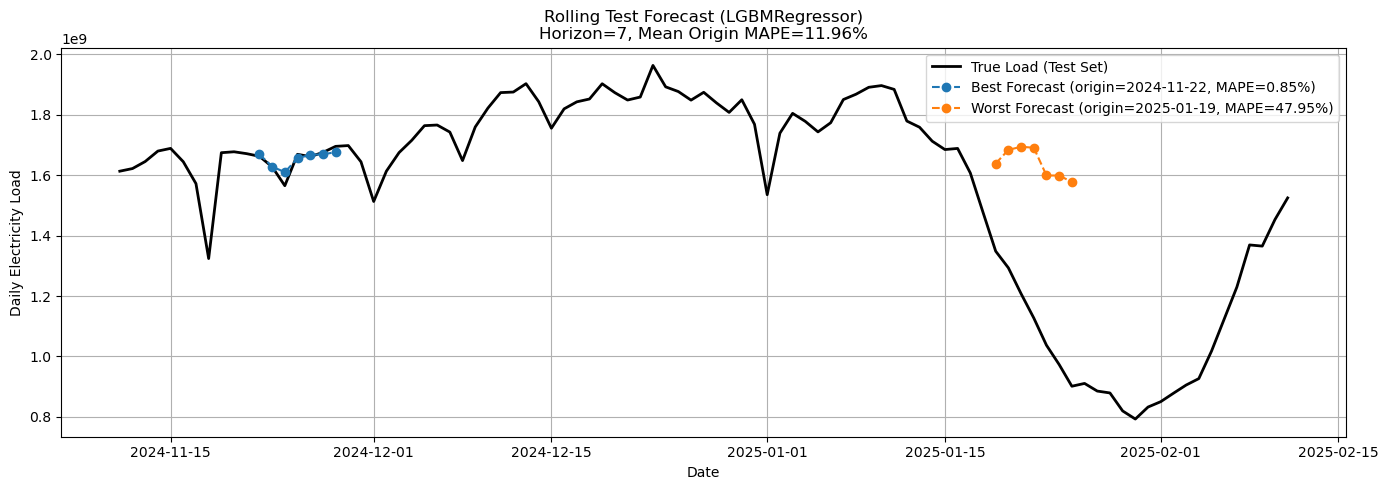

{'model_name': 'LGBMRegressor', 'val_overall_mape': 5.39369674059777, 'overall_mape': 11.964178167981288, 'skipped': False, 'skip_reason': None, 'artifact_dir': 'artifacts\\LGBMRegressor_feat\\20260409_164934', 'best_model_path': None, 'rolling_raw_path': 'artifacts\\LGBMRegressor_feat\\20260409_164934\\rolling_test_raw.csv'}
rolling_raw_path: artifacts\LGBMRegressor_feat\20260409_164934\rolling_test_raw.csv


In [21]:
from lightgbm import LGBMRegressor

lgbm_spec = ModelSpec(
    name='LGBMRegressor',
    model_type='ml',
    model_cls=LGBMRegressor,
    model_params={
        'n_estimators': 200,
        'random_state': RANDOM_SEED,
    },
    supports_future_exog=True,
)

lgbm_result = runner.run(lgbm_spec)
print(lgbm_result.summary())
print(f"rolling_raw_path: {lgbm_result.rolling_raw_path}")
